# Pandas Practice: Bike Share Trip Data

This notebook gives you practice using Pandas on a messier, more realistic dataset. You'll work with February 2014 trip data from a bike share scheme, cleaning column names, exploring patterns, filtering, grouping, and creating visualisations. A good data scientist doesn't always invent solutions from scratch; knowing where to look and how to adapt existing code is a core skill. If you get stuck, [Sebastian Raschka's Pandas tips](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb) and the [Pandas documentation](https://pandas.pydata.org/docs/) are excellent references.

---

<center><img src="../assets/nextbike_bike_rental_berlin.jpg" width="800"/></center>

In [1]:
# --- Starter code: run this cell first ---
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/bike_share_201402_trip_data.csv")
df.head()

,Trip ID,Duration,Start Date,Start Station,Start Terminal,End Date,End Station,End Terminal,Bike #,Subscription Type,Zip Code
0,4576,63,8/29/2013 14:13,South Van Ness at Market,66,8/29/2013 14:14,South Van Ness at Market,66,520,Subscriber,94127
1,4607,70,8/29/2013 14:42,San Jose City Hall,10,8/29/2013 14:43,San Jose City Hall,10,661,Subscriber,95138
2,4130,71,8/29/2013 10:16,Mountain View City Hall,27,8/29/2013 10:17,Mountain View City Hall,27,48,Subscriber,97214
3,4251,77,8/29/2013 11:29,San Jose City Hall,10,8/29/2013 11:30,San Jose City Hall,10,26,Subscriber,95060
4,4299,83,8/29/2013 12:02,South Van Ness at Market,66,8/29/2013 12:04,Market at 10th,67,319,Subscriber,94103


## Part 1: Cleaning and Exploring

### Challenge 1: How many trips are in the dataset?

Find the number of observations (rows) in the DataFrame.

In [ ]:
# YOUR CODE HERE
df.describe()

### Challenge 2: Make the column names Pythonic

Rename all columns so they are:
- **Lowercase**
- Spaces replaced with `_`
- `#` replaced with `num`

Print the updated column names to verify.

In [2]:
# YOUR CODE HERE
df.columns = [col.lower().replace(" ", "_").replace("#", "num") for col in df.columns]
df.columns

Index(['trip_id', 'duration', 'start_date', 'start_station', 'start_terminal',
       'end_date', 'end_station', 'end_terminal', 'bike_num',
       'subscription_type', 'zip_code'],
      dtype='str')

---

## Part 2: Subscription Analysis

### Challenge 3: Subscription types

How many types of subscription are there? What are they?

In [19]:
# YOUR CODE HERE
# df.groupby('subscription_type').nunique()
# df.groupby('subscription_type').count()
# df.groupby('subscription_type').value_counts()
df['subscription_type'].unique()

<StringArray>
['Subscriber', 'Customer']
Length: 2, dtype: str

### Challenge 4: Frequency of each subscription type

How many trips were made by each subscription type?

In [34]:
# YOUR CODE HERE
# df.groupby('subscription_type')['trip_id'].count()
# df.groupby('subscription_type')['trip_id']
# df.groupby('subscription_type').count()
# df["subscription_type"].count()
df["subscription_type"].value_counts()

subscription_type
Subscriber    113647
Customer       30368
Name: count, dtype: int64

### Challenge 5: Visualise subscription frequency, pie chart

Plot the frequency of each subscription type as a pie chart.

<Axes: >

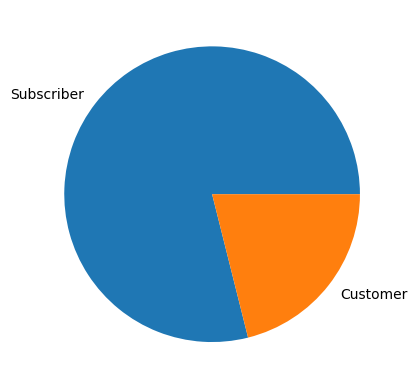

In [28]:
# YOUR CODE HERE
# df.groupby('subscription_type')['trip_id'].plot(
#     kind="pie",
#     title="Customers vs Subscribers"
# )
# plt.show()

df["subscription_type"].value_counts().plot(
    kind="pie",
    )

# df.groupby('subscription_type')['trip_id'].count().plot(kind="pie")

# df["subscription_type"].value_counts()

### Challenge 6: Visualise subscription frequency, bar chart

Plot the same data as a bar chart.

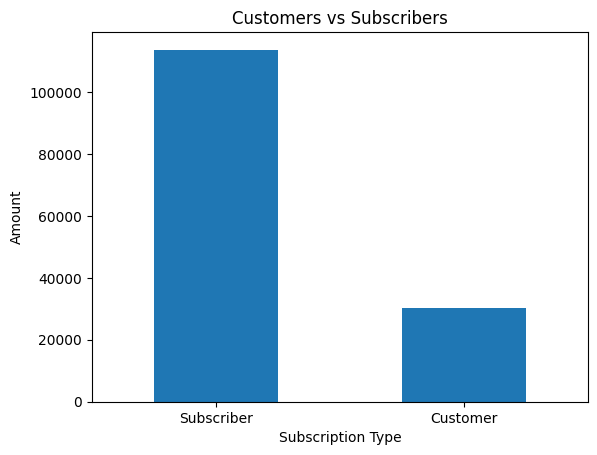

In [39]:
# YOUR CODE HERE

df["subscription_type"].value_counts().plot(
    kind="bar",
    title="Customers vs Subscribers",
    rot=0,
    )
plt.xlabel("Subscription Type")
plt.ylabel("Amount")
plt.show()

---

## Part 3: Station Analysis

### Challenge 7: Top 10 most popular start stations

Which 10 start stations appear most frequently in the data?

In [41]:
# YOUR CODE HERE
df['start_station'].value_counts().head(10)

start_station
San Francisco Caltrain (Townsend at 4th)         9838
Harry Bridges Plaza (Ferry Building)             7343
Embarcadero at Sansome                           6545
Market at Sansome                                5922
Temporary Transbay Terminal (Howard at Beale)    5113
Market at 4th                                    5030
2nd at Townsend                                  4987
San Francisco Caltrain 2 (330 Townsend)          4976
Steuart at Market                                4913
Townsend at 7th                                  4493
Name: count, dtype: int64

### Challenge 8: 10 least popular end stations

Which 10 end stations appear least often?

In [42]:
# YOUR CODE HERE
df['end_station'].value_counts().tail(10)

end_station
Broadway St at Battery St           205
Redwood City Medical Center         178
Castro Street and El Camino Real    129
Redwood City Public Library         117
San Mateo County Center             106
Franklin at Maple                    93
San Antonio Shopping Center          93
Broadway at Main                     56
San Jose Government Center           23
Mezes Park                            5
Name: count, dtype: int64

### Challenge 9: Cross-tabulation of start stations by subscription type

Create a table that shows the count of trips for each `start_station` segmented by `subscription_type`, including row and column totals (subtotals).

> Hint: look up `pd.crosstab()` in the documentation.

In [45]:
# YOUR CODE HERE

pd.crosstab(df['start_station'],df['subscription_type'])
#pd.crosstab(df['subscription_type'],df['start_station'])

subscription_type,Customer,Subscriber
start_station,,
2nd at Folsom,427,3349
2nd at South Park,535,3923
2nd at Townsend,882,4105
5th at Howard,606,2029
Adobe on Almaden,75,260
...,...,...
Temporary Transbay Terminal (Howard at Beale),427,4686
Townsend at 7th,518,3975
University and Emerson,328,106


---

## Part 4: Trip Duration

### Challenge 10: Explore duration

What unit do you think the `duration` column uses? Find the shortest and longest trips. How many trips are as short as the minimum?

In [ ]:
# YOUR CODE HERE

# unit = probably minutes ?

min = df['duration'].min()
max = df['duration'].max()

# how many trips are as short as the minium
df[df['duration'] == min]['duration'].count()

np.int64(17)

### Challenge 11: Define and count "long" trips

Define what you consider a "long" trip (justify your threshold). How many trips meet that definition? What might explain the very long durations?

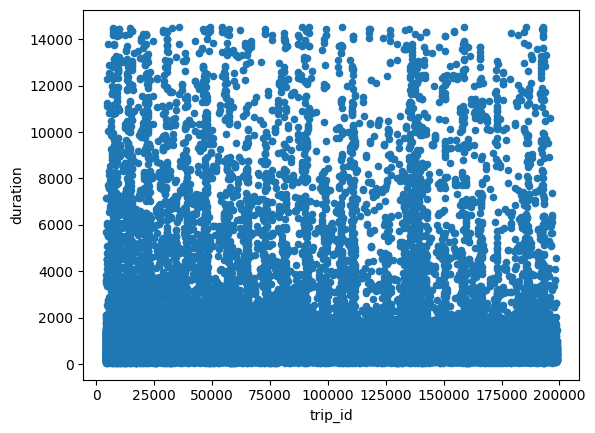

In [ ]:
# YOUR CODE HERE

mean = df['duration'].mean()
deviation = df['duration'].std()

cleandf = df[(df['duration'] > mean - (2 * deviation)) & (df['duration'] < mean + (2 * deviation))]
cleandf.plot(
    kind="scatter",
    x="trip_id",
    y="duration"
)
plt.show()

# very long durations are probably in seconds or something like that


### Challenge 12: Plot the duration distribution

Create a histogram of the `duration` column. Does it give clear insights? If not, filter to a more meaningful range and re-plot.

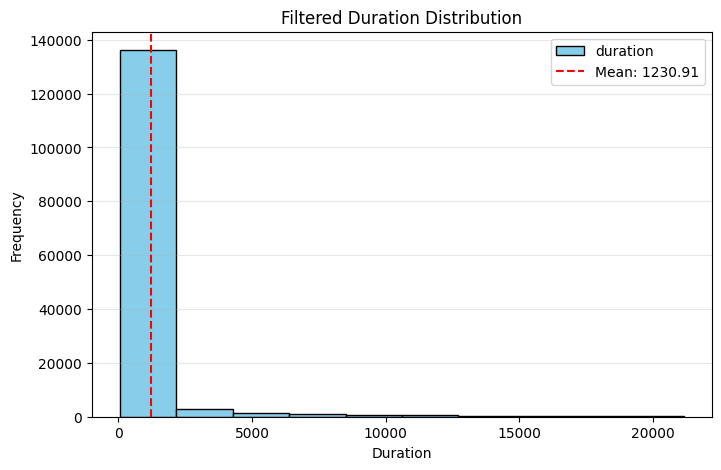

In [89]:
# YOUR CODE HERE

stats = df['duration'].describe()

mean_val = stats['mean']
std_val = stats['std']

lower_bound = mean_val - (3 * std_val)
upper_bound = mean_val + (3 * std_val)

df_filtered = df[(df['duration'] >= lower_bound) & (df['duration'] <= upper_bound)]

plt.figure(figsize=(8, 5))

df_filtered['duration'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.title('Filtered Duration Distribution')
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()



---

## Part 5: Data Cleaning (Advanced)

### Challenge 13: Normalise station names

The product team wants all station names to be lowercase with underscores as separators.

Example: `South Van Ness at Market` → `south_van_ness_at_market`

Apply this transformation to both the `start_station` and `end_station` columns.

> **Do NOT use a for loop.** Use a vectorised Pandas string method instead, it will be much faster.

In [93]:
# YOUR CODE HERE
df['start_station'].str.lower().str.replace(' ', '_')

0                  south_van_ness_at_market
1                        san_jose_city_hall
2                   mountain_view_city_hall
3                        san_jose_city_hall
4                  south_van_ness_at_market
                        ...                
144010                   powell_street_bart
144011             commercial_at_montgomery
144012               embarcadero_at_sansome
144013    civic_center_bart_(7th_at_market)
144014                    2nd_at_south_park
Name: start_station, Length: 144015, dtype: str

### Challenge 14: Open-ended exploration

Set a 15-minute timer. Use that time to explore the data guided by your own curiosity or hypotheses. What patterns can you find?

> Time-boxing is a useful technique when exploring new data: it prevents you from falling into rabbit holes and forces you to prioritise the most interesting questions.

In [ ]:
# YOUR CODE HERE